# Ejercicio 1: Evaluación de Solicitud de Crédito Bancario

**Curso:** IS-484 Inteligencia Artificial I  
**Práctica Calificada 001**  
**Alumno:** Aguilar Flores, Crisólogo  
**Ciclo:** 2026-II

---
## Ficha PEAS

| Componente | Descripción |
|---|---|
| **Percepción (S)** | `ingreso_mensual` (soles), `monto_solicitado` (soles), `tiene_historial_moroso` (bool) |
| **Acciones (A)** | `aprobar`, `aprobar_con_condiciones`, `rechazar` |
| **Entorno (E)** | Sistema financiero bancario. Observable (datos declarados), estático durante la evaluación, discreto, episódico (cada solicitud se evalúa de forma independiente) |
| **Objetivo** | Maximizar la rentabilidad del banco minimizando el riesgo de impago, garantizando acceso al crédito a clientes solventes |
| **Medida de desempeño (P)** | Tasa de morosidad de la cartera aprobada, tasa de rechazo de solicitudes solventes, ingresos por intereses generados |

---
## Reglas de Decisión

Se define la **relación** = `monto_solicitado / ingreso_mensual`.

| Condición | Acción |
|---|---|
| Sin historial moroso Y relación ≤ 3.0 | `aprobar` |
| Sin historial moroso Y 3.0 < relación ≤ 5.0 | `aprobar_con_condiciones` |
| Sin historial moroso Y relación > 5.0 | `rechazar` |
| Con historial moroso Y relación ≤ 2.0 | `aprobar_con_condiciones` |
| Con historial moroso Y relación > 2.0 | `rechazar` |

### Justificación de las reglas

La relación monto/ingreso mensual es un indicador estándar de capacidad de pago: un cliente que solicita crédito equivalente a más de 5 veces su ingreso mensual tiene una carga financiera extremadamente difícil de sostener, por lo que el rechazo protege tanto al banco como al cliente del sobreendeudamiento. Para clientes sin historial moroso, se flexibiliza el umbral (hasta 3x para aprobación directa, hasta 5x con condiciones como aval o seguro), reconociendo su trayectoria positiva. Cuando existe historial moroso, el umbral baja a 2x porque la evidencia estadística indica mayor probabilidad de impago; no obstante, se contempla la aprobación con condiciones para relaciones bajas, dando una segunda oportunidad sin descuidar el riesgo. Este enfoque equilibra inclusión financiera y gestión responsable del riesgo crediticio.

---
## Código

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Agente evaluador de solicitudes de crédito bancario.
    
    Parámetros:
        ingreso_mensual (float): Ingreso mensual del solicitante en soles.
        monto_solicitado (float): Monto del crédito solicitado en soles.
        tiene_historial_moroso (bool): True si el cliente tiene historial de morosidad.
    
    Retorna:
        tuple: (accion: str, motivo: str)
    """
    if ingreso_mensual <= 0:
        return "rechazar", "ingreso mensual inválido o igual a cero"
    
    relacion = monto_solicitado / ingreso_mensual
    
    if not tiene_historial_moroso:
        if relacion <= 3.0:
            return ("aprobar",
                    f"relacion monto/ingreso de {relacion:.2f} dentro del rango seguro, "
                    f"sin historial moroso")
        elif relacion <= 5.0:
            return ("aprobar_con_condiciones",
                    f"relacion monto/ingreso de {relacion:.2f} es moderada, "
                    f"se requiere aval o seguro de desgravamen")
        else:
            return ("rechazar",
                    f"relacion monto/ingreso de {relacion:.2f} supera el limite maximo (5.0), "
                    f"carga financiera insostenible")
    else:
        if relacion <= 2.0:
            return ("aprobar_con_condiciones",
                    f"relacion monto/ingreso de {relacion:.2f} es baja pero existe "
                    f"historial moroso; se aprueba con condiciones reforzadas")
        else:
            return ("rechazar",
                    f"relacion monto/ingreso de {relacion:.2f} con historial moroso "
                    f"supera el umbral permitido (2.0)")

print("Función agente_credito definida correctamente.")

Función agente_credito definida correctamente.


---
## Simulación y Pruebas

Se prueban 6 combinaciones, incluyendo casos borde.

In [3]:
casos_prueba = [
    # (ingreso_mensual, monto_solicitado, tiene_historial_moroso, descripcion)
    (3000, 6000,  False, "Caso 1 — Relación 2.0, sin morosidad  → APROBAR"),
    (2000, 8000,  False, "Caso 2 — Relación 4.0, sin morosidad  → APROBAR CON CONDICIONES"),
    (1500, 9000,  False, "Caso 3 — Relación 6.0, sin morosidad  → RECHAZAR"),
    (4000, 8000,  True,  "Caso 4 — Relación 2.0, con morosidad  → BORDE: APROBAR CON CONDICIONES"),
    (4000, 8001,  True,  "Caso 5 — Relación >2.0, con morosidad → RECHAZAR"),
    (5000, 15000, True,  "Caso 6 — Relación 3.0, con morosidad  → RECHAZAR"),
]

print("=" * 70)
print("SIMULACIÓN DE SOLICITUDES DE CRÉDITO")
print("=" * 70)

for ingreso, monto, moroso, desc in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso
    print(f"\n{desc}")
    print(f"  Ingreso: S/ {ingreso:,.0f} | Monto: S/ {monto:,.0f} | "
          f"Relación: {relacion:.4f} | Moroso: {moroso}")
    print(f"  → Acción : {accion.upper()}")
    print(f"  → Motivo : {motivo}")

print("\n" + "=" * 70)

SIMULACIÓN DE SOLICITUDES DE CRÉDITO

Caso 1 — Relación 2.0, sin morosidad  → APROBAR
  Ingreso: S/ 3,000 | Monto: S/ 6,000 | Relación: 2.0000 | Moroso: False
  → Acción : APROBAR
  → Motivo : relacion monto/ingreso de 2.00 dentro del rango seguro, sin historial moroso

Caso 2 — Relación 4.0, sin morosidad  → APROBAR CON CONDICIONES
  Ingreso: S/ 2,000 | Monto: S/ 8,000 | Relación: 4.0000 | Moroso: False
  → Acción : APROBAR_CON_CONDICIONES
  → Motivo : relacion monto/ingreso de 4.00 es moderada, se requiere aval o seguro de desgravamen

Caso 3 — Relación 6.0, sin morosidad  → RECHAZAR
  Ingreso: S/ 1,500 | Monto: S/ 9,000 | Relación: 6.0000 | Moroso: False
  → Acción : RECHAZAR
  → Motivo : relacion monto/ingreso de 6.00 supera el limite maximo (5.0), carga financiera insostenible

Caso 4 — Relación 2.0, con morosidad  → BORDE: APROBAR CON CONDICIONES
  Ingreso: S/ 4,000 | Monto: S/ 8,000 | Relación: 2.0000 | Moroso: True
  → Acción : APROBAR_CON_CONDICIONES
  → Motivo : relacion mont

---
## Visualización

Generación de 200 solicitudes aleatorias y scatter plot coloreado por decisión del agente.

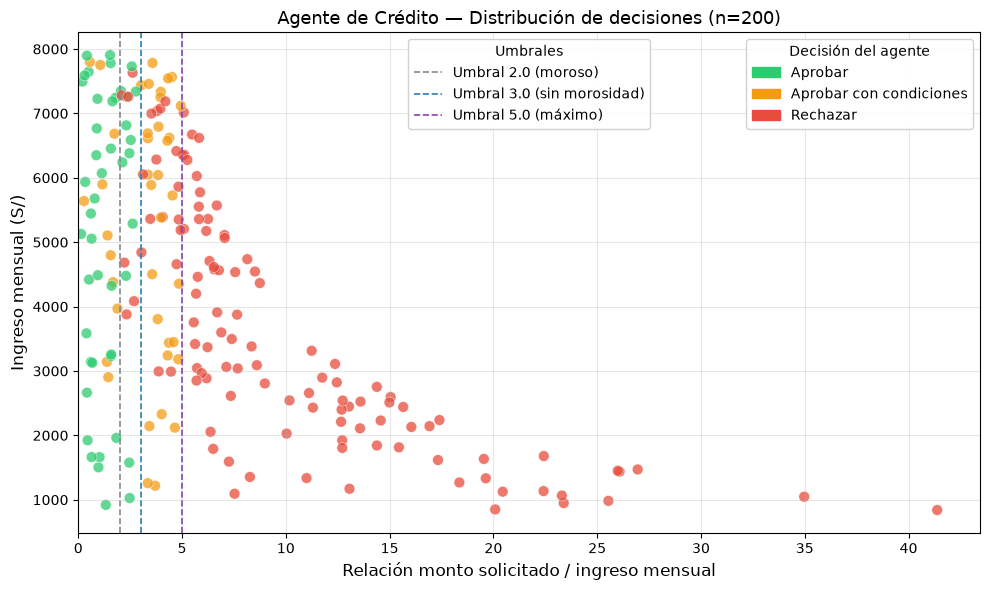


Distribución de decisiones:
  rechazar                    : 114 solicitudes (57.0%)
  aprobar                     :  45 solicitudes (22.5%)
  aprobar_con_condiciones     :  41 solicitudes (20.5%)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
N = 200

# Generación aleatoria de solicitudes
ingresos   = np.random.uniform(800, 8000, N)          # ingresos entre S/800 y S/8000
montos     = np.random.uniform(500, 40000, N)          # montos entre S/500 y S/40000
morosos    = np.random.choice([True, False], size=N, p=[0.3, 0.7])  # 30% con morosidad

# Calcular decisión para cada solicitud
acciones   = []
relaciones = []

for i in range(N):
    accion, _ = agente_credito(ingresos[i], montos[i], morosos[i])
    acciones.append(accion)
    relaciones.append(montos[i] / ingresos[i])

acciones   = np.array(acciones)
relaciones = np.array(relaciones)

# Mapa de colores por decisión
color_map = {
    "aprobar":                 "#2ecc71",   # verde
    "aprobar_con_condiciones": "#f39c12",   # naranja
    "rechazar":                "#e74c3c",   # rojo
}
colores = [color_map[a] for a in acciones]

# ---- Figura principal ----
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(relaciones, ingresos, c=colores, alpha=0.75, edgecolors="white",
           linewidths=0.4, s=60)

# Líneas de umbral clave
ax.axvline(x=2.0, color="#7f8c8d", linestyle="--", linewidth=1.2,
           label="Umbral 2.0 (moroso)")
ax.axvline(x=3.0, color="#2980b9", linestyle="--", linewidth=1.2,
           label="Umbral 3.0 (sin morosidad)")
ax.axvline(x=5.0, color="#8e44ad", linestyle="--", linewidth=1.2,
           label="Umbral 5.0 (máximo)")

# Leyenda de decisiones
patches = [
    mpatches.Patch(color="#2ecc71", label="Aprobar"),
    mpatches.Patch(color="#f39c12", label="Aprobar con condiciones"),
    mpatches.Patch(color="#e74c3c", label="Rechazar"),
]
legend1 = ax.legend(handles=patches, title="Decisión del agente",
                    loc="upper right", framealpha=0.9)
ax.add_artist(legend1)
ax.legend(title="Umbrales", loc="upper center", framealpha=0.9)

ax.set_xlabel("Relación monto solicitado / ingreso mensual", fontsize=12)
ax.set_ylabel("Ingreso mensual (S/)", fontsize=12)
ax.set_title("Agente de Crédito — Distribución de decisiones (n=200)", fontsize=13)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_credito.png", dpi=150)
plt.show()

# ---- Conteo de decisiones ----
from collections import Counter
conteo = Counter(acciones)
print("\nDistribución de decisiones:")
for decision, count in conteo.items():
    print(f"  {decision:<28}: {count:>3} solicitudes ({count/N*100:.1f}%)")